In [1]:
import jax
import numpy as np

from crn_jax import models
from crn_jax.plotting import plot_species_trajectories

## Setup

In [2]:
key = jax.random.PRNGKey(0)

In [3]:
def run_and_plot(model, x0, n_steps: int = 1000, params=None, title=None):
    """Simulate one trajectory of ``model`` with initial counts ``x0`` and plot per-species.

    The initial state ``x0`` is a list or array of length ``len(model.SPECIES)``.
    We reshape to ``(1, S)`` for the (n_replicates, n_species) interface of ``sample_trajectories``.
    ``params`` defaults to ``model.Params.default()`` if not supplied — pass a different
    ``Params`` instance (e.g. ``Params.bistable()``) to override the regime.
    """
    if params is None:
        params = model.Params.default()
    print("Params:", params.__dict__)
    x0_arr = np.asarray(x0, dtype=np.float32).reshape(1, len(model.SPECIES))
    dataset = models.sample_trajectories(model, params=params, key=key, x0=x0_arr, dt=0.1, n_steps=n_steps)

    if title is None:
        title = model.__name__.rsplit(".", 1)[-1]

    return plot_species_trajectories(dataset, title=title)

## Single-trajectory (N=1) examples

Params: {'alpha': 5.0, 'delta': 1.0}


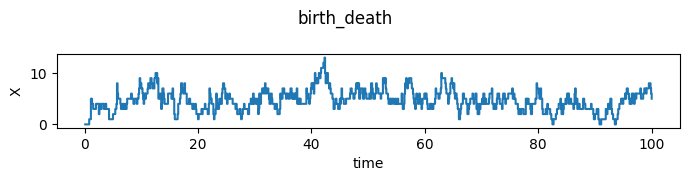

In [ ]:
# Birth-death. A single species is produced at a constant rate and decays first-order;
# the stationary distribution is Poisson with mean α/δ.
# Species: X (the species count).
run_and_plot(models.birth_death, x0=[0]);  # start empty; relaxes toward ⟨X⟩ = α/δ = 5

Params: {'k_R': 0.6, 'gamma_R': 0.3466, 'k_P': 6.931, 'gamma_P': 0.01155}


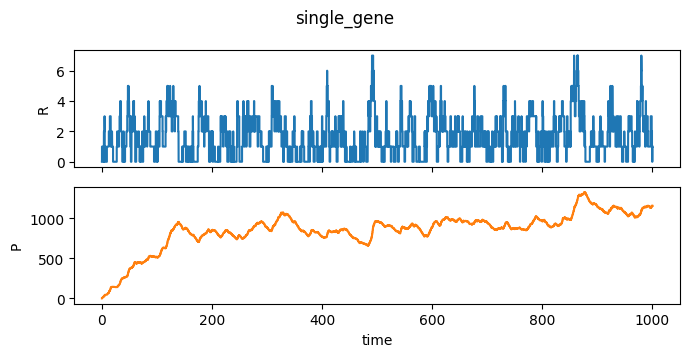

In [ ]:
# Single-gene expression. Transcription produces mRNA constitutively, which is then
# translated into protein; both species decay first-order. The simplest model with a
# hidden delay between input and output.
# Species: R (mRNA), P (protein).

# Start empty: watch how mRNA increases drives protein expression
run_and_plot(models.single_gene, x0=[0, 0], n_steps=10000);

Params: {'beta_0': 0.0, 'beta_1': 0.05776, 'K': 1.0, 'n': 1.0, 'delta': 0.01155}


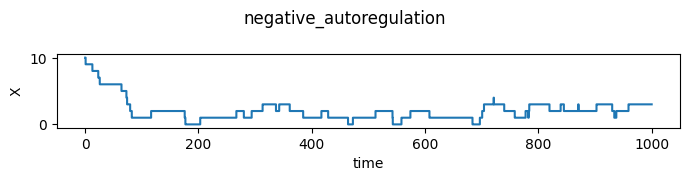

In [ ]:
# Negative autoregulation. A single species represses its own production through a Hill
# term — a classic noise-reducing motif that speeds up response and tightens the
# stationary distribution compared to unregulated expression.
# Species: X (the species count).

# Start above SS so the self-repression visibly pulls X down
run_and_plot(models.negative_autoregulation, x0=[10], n_steps=10000);

Params: {'beta_0': 0.005776, 'beta_1': 0.05776, 'K': 1.0, 'n': 1.0, 'delta': 0.01155}


(<Figure size 700x180 with 1 Axes>,
 array([<Axes: xlabel='time', ylabel='X'>], dtype=object))

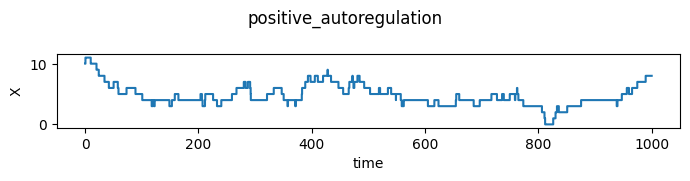

In [4]:
# Positive autoregulation. A single species activates its own production through a Hill
# term. With sub-cooperative Hill (n ≤ 1) the equilibrium is monostable and graded; with
# sharper cooperativity and lower leakage the dynamics become switch-like — see the
# next cell for the bistable regime of this same circuit.
# Species: X (the species count).

# Start above SS to see the slow relaxation to SS
run_and_plot(models.positive_autoregulation, x0=[10], n_steps=10000)

Params: {'beta_0': 0.0, 'beta_1': 0.5776, 'K': 20.0, 'n': 4.0, 'delta': 0.01155}
Params: {'beta_0': 0.0, 'beta_1': 0.5776, 'K': 20.0, 'n': 4.0, 'delta': 0.01155}


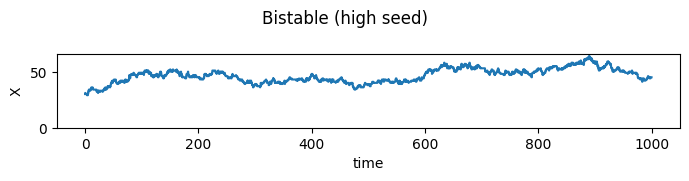

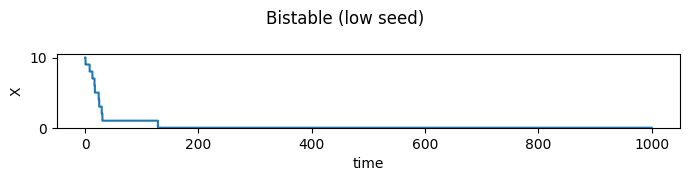

In [7]:
# Bistable self-activation — the same circuit as positive_autoregulation, just in
# the bistable parameter regime.
# Three deterministic fixed points: X=0 (stable, absorbing), X_saddle ≈ 17, X_high ≈ 49.
# Trajectories starting above the saddle commit to the high attractor; below, they
# fall to and stay at zero (β₀ = 0, so X=0 is absorbing).
# Species: X (the species count).

# Seed above the saddle
fig, ax = run_and_plot(
    models.positive_autoregulation,
    x0=[30],
    params=models.positive_autoregulation.Params.bistable(),
    n_steps=10000,
    title="Bistable (high seed)",
)

# Seed below the saddle
fig, ax = run_and_plot(
    models.positive_autoregulation,
    x0=[10],
    params=models.positive_autoregulation.Params.bistable(),
    n_steps=10000,
    title="Bistable (low seed)",
)

Params: {'alpha_A': 0.05776, 'delta_A': 0.01155, 'beta_B0': 0.0005776, 'beta_B1': 0.05776, 'K_A': 5.0, 'n_A': 1.0, 'delta_B': 0.01155}


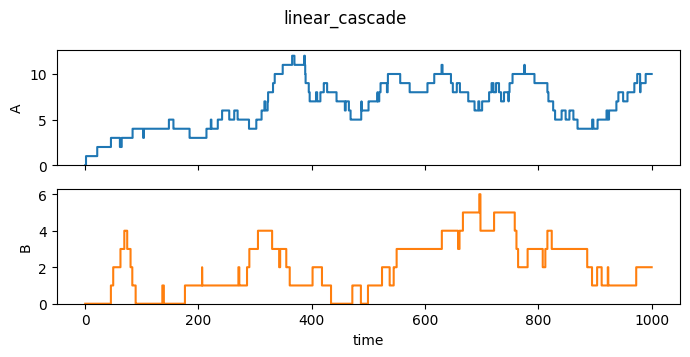

In [5]:
# Linear activation cascade. A is produced at a constant rate and decays first-order.
# A then activates B through a Hill term. The simplest open signalling cascade — useful as
# a baseline for studying propagation delay.
# Species: A (upstream driver), B (downstream target).
# K_A is tuned to ⟨A⟩=5 so the cascade sits at half-activation and B tracks A's variations.

# Start empty: A rises first, then drives B
run_and_plot(models.linear_cascade, x0=[0, 0], n_steps=10000);

Params: {'beta_A0': 15.6, 'beta_A1': 156.25, 'beta_B0': 0.0, 'beta_B1': 15.6, 'K_A': 2.0015, 'K_B': 2.9618e-05, 'n_A': 1.0, 'n_B': 2.5, 'delta_A': 1.0, 'delta_B': 1.0}


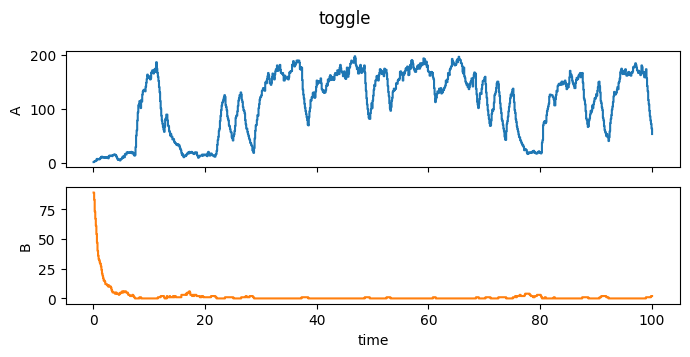

In [11]:
# Toggle switch. Two species mutually repress each other (Gardner-Cantor-Collins, 2000);
# for sharp enough Hill cooperativity the system is bistable, settling into either an
# "A-high, B-low" or "A-low, B-high" state.
# Species: A, B (mutually repressing genes).
run_and_plot(models.toggle, x0=[0, 100])  # seed B high → trajectory commits to the B-dominant basin

Params: {'beta_A0': 0.05, 'beta_A1': 5.0, 'K_B': 1.0, 'n_B': 1.0, 'delta_A': 1.0, 'beta_B0': 0.05, 'beta_B1': 5.0, 'K_A': 1.0, 'n_A': 1.0, 'delta_B': 1.0}


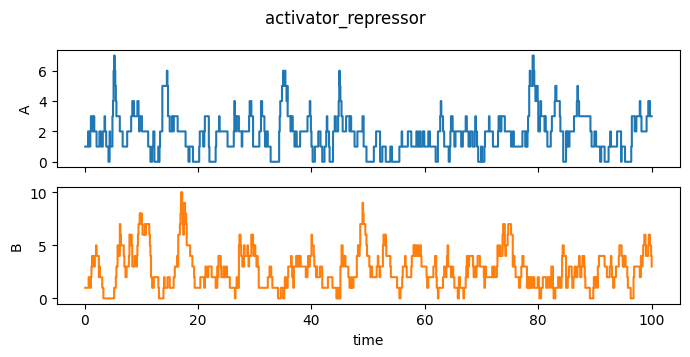

In [12]:
# Activator-repressor pair. Mixed-sign two-node feedback: A activates B and B represses A.
# For suitable parameters this circuit can produce sustained oscillations (a relaxation
# oscillator) — the simplest two-node motif that ticks.
# Species: A (activator), B (repressor).
run_and_plot(models.activator_repressor, x0=[0, 0])  # leak terms get A going, which then drives B

Params: {'beta_A0': 0.05, 'beta_A1': 5.0, 'K_B': 1.0, 'n_B': 1.0, 'delta_A': 1.0, 'beta_B0': 0.05, 'beta_B1': 5.0, 'K_A': 1.0, 'n_A': 1.0, 'delta_B': 1.0}


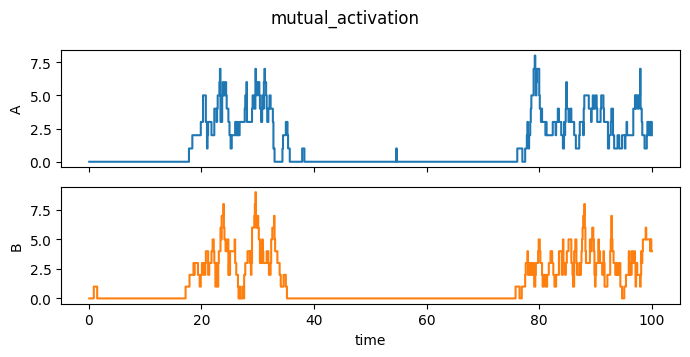

In [13]:
# Mutual activation. Two species activate each other through Hill terms. This positive
# two-node feedback can amplify small fluctuations into bistability under sharp Hill
# cooperativity.
# Species: A, B (mutually activating genes).
run_and_plot(models.mutual_activation, x0=[0, 0])  # both start empty; leak terms seed the mutual escape

Params: {'a': 1.0, 'Ty': 0.5, 'Tz': 0.5}


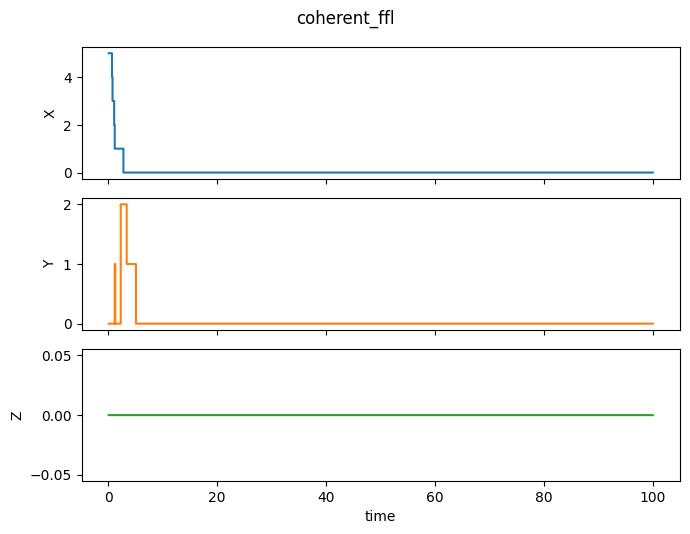

In [14]:
# Coherent feed-forward loop (AND logic). X drives Y, and X and Y together gate Z; X is
# not produced by the model (it enters as an initial condition and decays). The
# AND-gate at Z introduces a sign-sensitive delay: Z only responds to sustained X pulses.
# Species: X (input pulse), Y (intermediate), Z (output).
run_and_plot(models.coherent_ffl, x0=[5, 0, 0])  # X above threshold Ty=0.5 — required for any Y / Z activity

Params: {'alpha_A': 5.0, 'delta_A': 1.0, 'beta_B0': 0.05, 'beta_B1': 5.0, 'K_A': 1.0, 'n_A': 1.0, 'delta_B': 1.0, 'beta_C0': 0.05, 'beta_C1': 5.0, 'K_B': 1.0, 'n_B': 1.0, 'delta_C': 1.0}


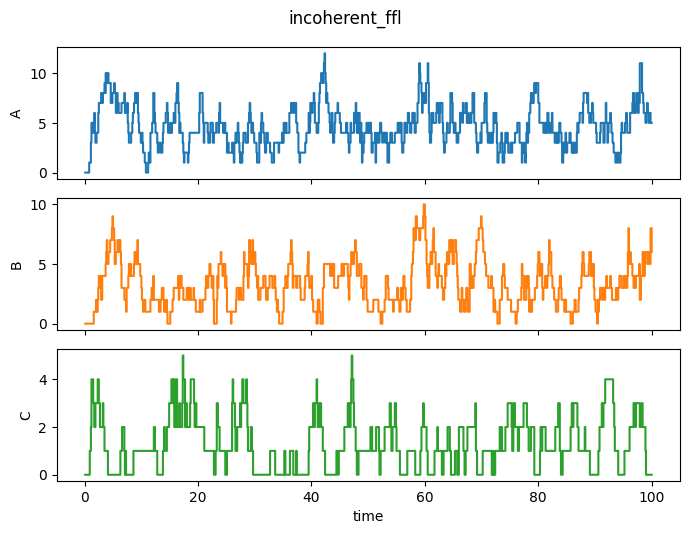

In [15]:
# Incoherent feed-forward loop. A activates both B and C, while B represses C. The opposing
# direct (A→C) and indirect (A→B⊣C) paths produce a pulse / adaptive response on C: C
# transiently rises after A turns on, then falls as the slower repression through B kicks in.
# Species: A (input), B (intermediate repressor), C (output).
run_and_plot(models.incoherent_ffl, x0=[0, 0, 0])  # A grows from its constant production, then drives B and C

Params: {'beta_A0': 0.03, 'beta_A1': 29.97, 'beta_B0': 0.03, 'beta_B1': 29.97, 'beta_C0': 0.03, 'beta_C1': 29.97, 'K_A': 40.0, 'K_B': 40.0, 'K_C': 40.0, 'n': 2.0, 'delta_A': 0.347, 'delta_B': 0.347, 'delta_C': 0.347}


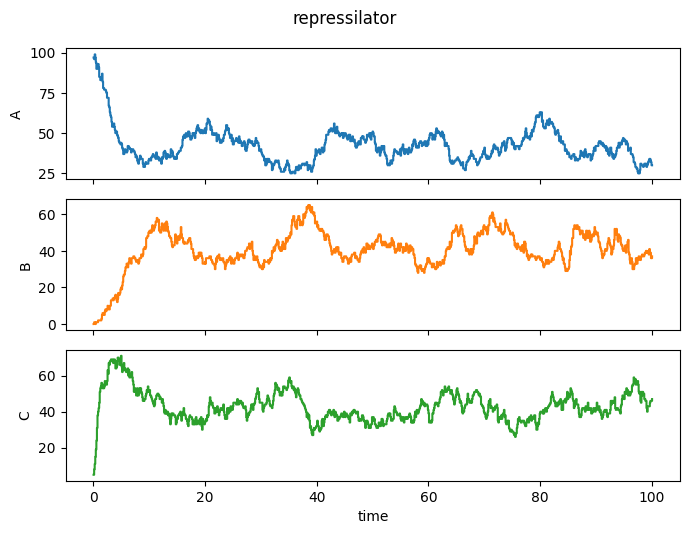

In [16]:
# Repressilator (Elowitz-Leibler, 2000). A three-node repressive ring in which A
# represses B, B represses C, and C represses A. With sufficient Hill cooperativity and a
# clear timescale separation the system enters a stable limit cycle — a synthetic oscillator.
# Species: A, B, C (the three mutually-repressing genes).
run_and_plot(
    models.repressilator, x0=[100, 0, 0]
)  # asymmetric IC breaks the ring's rotational symmetry, seeds the cycle

Params: {'beta_A0': 0.05, 'beta_A1': 5.0, 'K_C': 1.0, 'n_C': 1.0, 'delta_A': 1.0, 'beta_B0': 0.05, 'beta_B1': 5.0, 'K_A': 1.0, 'n_A': 1.0, 'delta_B': 1.0, 'beta_C0': 0.05, 'beta_C1': 5.0, 'K_B': 1.0, 'n_B': 1.0, 'delta_C': 1.0}


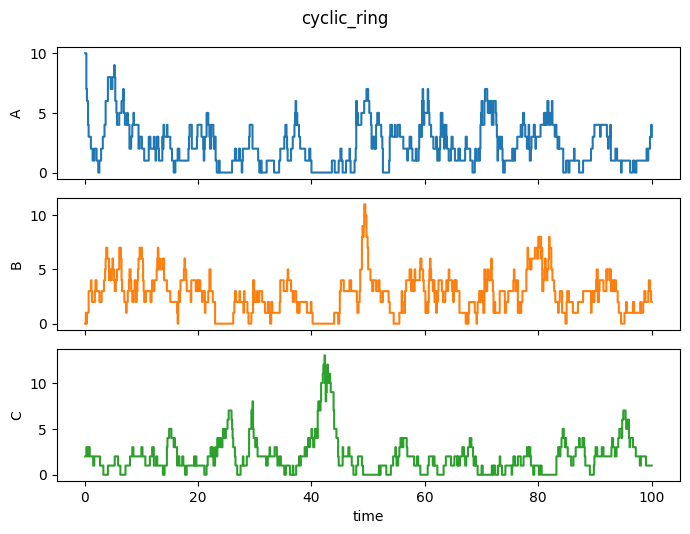

In [17]:
# Cyclic hybrid ring. A mixed-sign three-node loop in which C represses A, A activates B,
# and B represses C. The two repressors and one activator give qualitatively different
# dynamics from the pure-repressive repressilator.
# Species: A, B, C (the three species in the ring).
run_and_plot(models.cyclic_ring, x0=[10, 0, 0])  # asymmetric IC: A high → drives B up → which then represses C